# Question: Principle Component Analysis
# Author: G Mahendra Reddy
# Enrollment Number : 23114030

In [1]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

In [2]:
# Reading all the data
labels = pd.read_csv("class.tsv", header=None, names=["label"])
expression = pd.read_csv("filtered.tsv", sep="\t")
columns = pd.read_csv("columns.tsv", sep="\t", header=None,skiprows=19)

In [3]:
columns.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,1,cDNA_landinglight,IMAGE:2580289,B-actin_1/4,ACTB,Hs.520640,188.0,"AW081870, NM_001101",60,pCMV-SPORT6,NaN,1,1,1,NaN,NaN
1,2,cDNA_landinglight,IMAGE:2580289,B-actin_1/8,ACTB,Hs.520640,188.0,"AW081870, NM_001101",60,pCMV-SPORT6,NaN,1,2,1,NaN,NaN
2,3,cDNA_clone,BC DDP 2 E12,AL122097 DKFZp434P1215(unknown),NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,3,1,BC DDP 2 E12,NaN
3,4,cDNA_clone,BC DDP 2 G12,strange,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,4,1,BC DDP 2 G12,NaN
4,5,cDNA_clone,BC TAX 1 A06,XM_017216 hypothetical protein FLJ21127(unknown),NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,5,1,BC TAX 1 A06,NaN


In [4]:
# Mapping gene name to id
gene_name_map = dict(zip(columns[4], columns[0]))
# Finding id's fo "XBP1" & "GATA3"
xbp1_id=gene_name_map["XBP1"]
gata3_id=gene_name_map["GATA3"]
expression.columns=expression.columns.astype(int)
x = expression[gata3_id]
y = expression[xbp1_id]
label_colors = labels['label'].map({0: 'black', 1: 'red'})

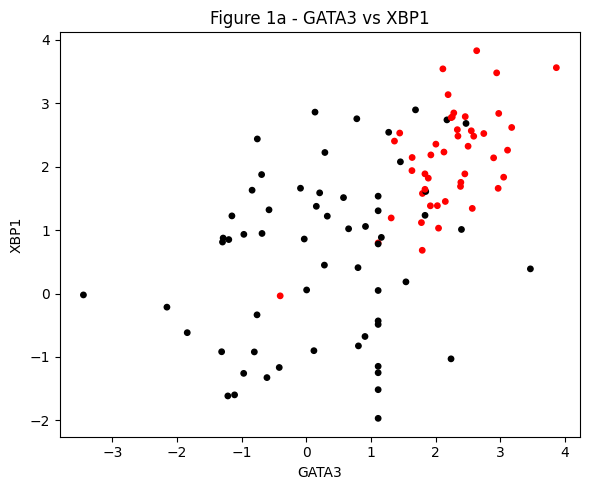

In [5]:
# Plotting scatter plot (GATA3 vs XBP1) for 105 patients
plt.figure(figsize=(6, 5))
plt.scatter(x, y, c=label_colors, s=15)
plt.xlabel("GATA3")
plt.ylabel("XBP1")
plt.title("Figure 1a - GATA3 vs XBP1")
plt.tight_layout()
plt.show()

/tmp/ipykernel_47436/1973297719.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


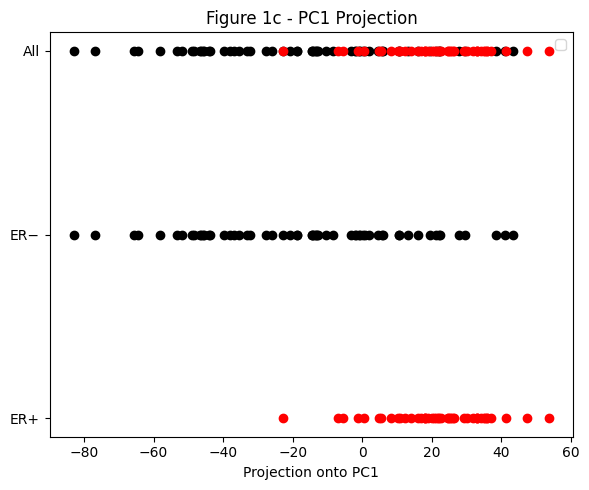

In [6]:
# Perform PCA on full expression matrix
pca = PCA()
X_pca = pca.fit_transform(expression)

# Plot projection onto PC1 for all, ER−, and ER+
plt.figure(figsize=(6, 5))

plt.plot(X_pca[labels['label'] == 0, 0], [2]*sum(labels['label'] == 0), 'o', color='black' )
plt.plot(X_pca[labels['label'] == 1, 0], [2]*sum(labels['label'] == 1), 'o', color='red')
plt.plot(X_pca[labels['label'] == 0, 0], [1]*sum(labels['label'] == 0), 'o', color='black' )
plt.plot(X_pca[labels['label'] == 1, 0], [0]*sum(labels['label'] == 1), 'o', color='red')
plt.yticks([0, 1, 2], ['ER+', 'ER−', 'All'])
plt.xlabel("Projection onto PC1")
plt.title("Figure 1c - PC1 Projection")
plt.tight_layout()
plt.legend()
plt.show()